In [2]:
import pandas as pd

In [3]:
import seaborn as sns
import numpy as np

In [4]:
df=pd.read_csv('df_zscore.csv')

<Axes: ylabel='Fare'>

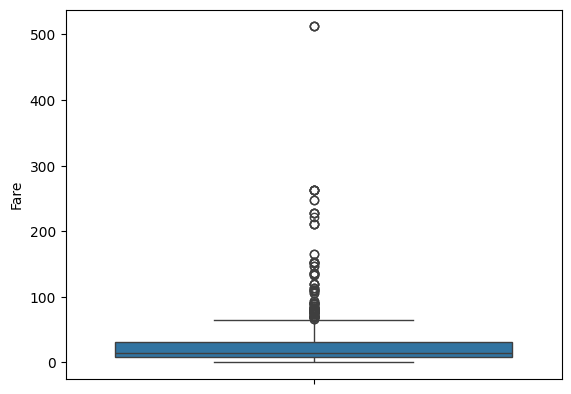

In [5]:
sns.boxplot(df['Fare'])

In [6]:
percentile25=df['Fare'].quantile(0.25)
percentile75=df['Fare'].quantile(0.75)
iqr=percentile75-percentile25
ub=percentile75+1.5*iqr
lb=percentile25-1.5*iqr
print('Upper bound is ',ub)
print('Lower bound is ',lb)

Upper bound is  65.6344
Lower bound is  -26.724


In [7]:
new_df=df[(df['Fare']<ub)&(df['Fare']>lb)]
print("Before Trimming",df.shape)
print("After Trimming",new_df.shape)
new_df['Fare'].describe()

Before Trimming (891, 12)
After Trimming (775, 12)


count    775.000000
mean      17.822091
std       13.578085
min        0.000000
25%        7.895800
50%       13.000000
75%       26.000000
max       65.000000
Name: Fare, dtype: float64

In [8]:
#capping
df['Fare']=np.where(
    df['Fare']>ub,
    ub,
    np.where(
     df['Fare']<lb,
     lb,
     df['Fare']
   )    
)

In [9]:
df['Fare'].describe()

count    891.000000
mean      24.046813
std       20.481625
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max       65.634400
Name: Fare, dtype: float64

In [10]:
df.to_csv('df_oh.csv',index=False)